# Hometask
1. Load the Electricity Consumption data in Romania (./datasets/electricity_consumption_and_production.csv). Use the Consumption column as the target variable.
2. Perform EDA: decompose the series, plot ACF and PACF, and run the ADF stationarity test. Note that the data contains hourly observations — resample to daily before performing forecast.
3. Clean data if necessary.
4. Train forecasting models (Use models from the lecture or other ones if you wish) and produce forecasts for 15, 30, and 45 days ahead.
5. Visualize predictions and provide evaluation metrics

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import torch

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from darts import TimeSeries
from darts.metrics import mape, mae, mse, mql
from darts.models import ARIMA, Prophet, XGBModel, Chronos2Model
from darts.utils.likelihood_models.torch import QuantileRegression

warnings.filterwarnings('ignore')

## Data Collection and Preprocessing

In [50]:
def preprocess_consumption(df: pd.DataFrame) -> pd.Series:
    series = df["Consumption"]
    
    series = series[~series.index.duplicated(keep="first")]
    
    full_range = pd.date_range(start=series.index.min(), end=series.index.max(), freq="h")
    series = series.reindex(full_range).interpolate(method="linear")
    
    return series.resample("D").mean()

electricity_consumption_df = pd.read_csv(
    'data/electricity_consumption_and_production.csv', 
    parse_dates=["DateTime"], 
    index_col="DateTime"
)

daily_consumption = preprocess_consumption(electricity_consumption_df)
print(f"Оброблено щоденних спостережень: {len(daily_consumption)} днів")

Оброблено щоденних спостережень: 2270 днів


## EDA

--- Тест стаціонарності ADF ---
ADF Statistic: -3.4057
p-value: 0.0108
Ряд стаціонарний (p < 0.05): True



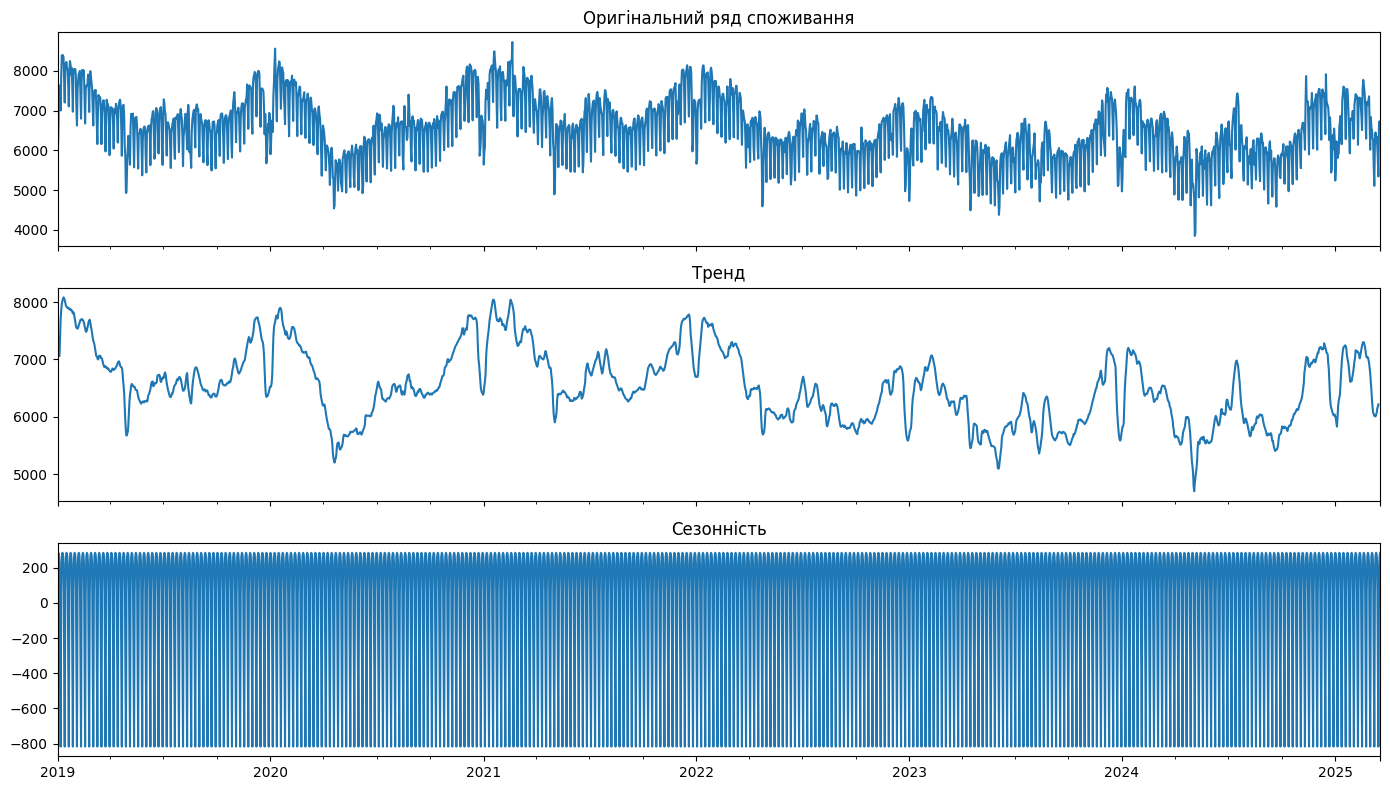

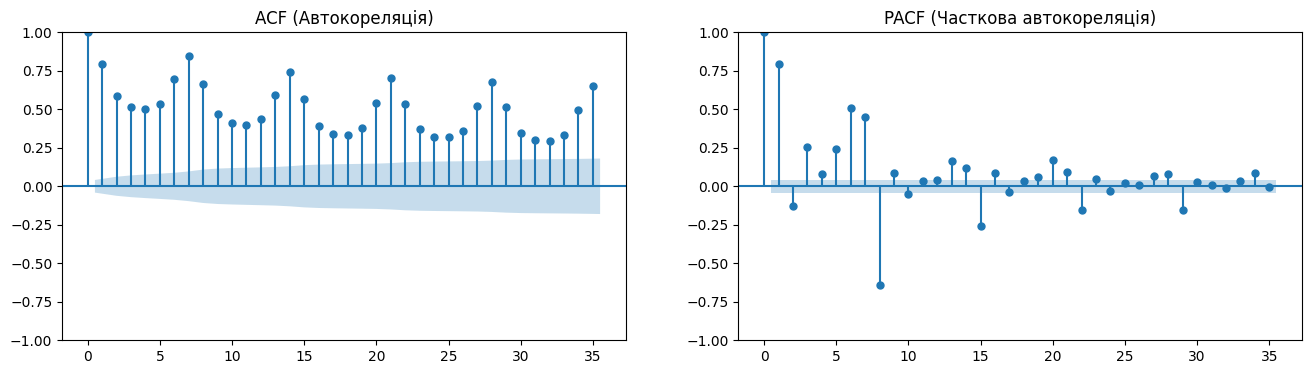

In [58]:
print("--- Тест стаціонарності ADF ---")
adf_result = adfuller(daily_consumption)
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print(f"Ряд стаціонарний (p < 0.05): {adf_result[1] < 0.05}\n")

decomposition = seasonal_decompose(daily_consumption, model='additive', period=7)
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
daily_consumption.plot(ax=axes[0], title='Оригінальний ряд споживання')
decomposition.trend.plot(ax=axes[1], title='Тренд')
decomposition.seasonal.plot(ax=axes[2], title='Сезонність')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(daily_consumption, lags=35, ax=axes[0], title="ACF (Автокореляція)")
plot_pacf(daily_consumption, lags=35, method="ywm", ax=axes[1], title="PACF (Часткова автокореляція)")
plt.show()

## Key Metrics & Visualization Templates

In [52]:
def visualize_multi_forecast(model_name, predictions, train_splits, val_splits, q_low=0.1, q_high=0.9):
    n = len(predictions)
    
    fig, axes = plt.subplots(n, 1, figsize=(14, 5 * n), sharex=False)
    if n == 1:
        axes = [axes]
    all_metrics = {}

    for ax, (horizon_key, pred_ts) in zip(axes, predictions.items()):
        train_ts  = train_splits[horizon_key]
        actual_ts = val_splits[horizon_key]
        is_prob   = pred_ts.n_samples > 1
        median    = pred_ts.quantile(0.5) if is_prob else pred_ts

        train_series_zoom = train_ts.to_series()
        train_series_zoom = train_series_zoom[train_series_zoom.index.year >= 2025]

        train_series_zoom.plot(ax=ax, label="Training data (from 2024)", color="steelblue", lw=1.8)
        actual_ts.to_series().plot(ax=ax, label="Actual values", color="green", lw=1.8)
        median.to_series().plot(ax=ax, label="Forecast (median)", color="tomato", lw=1.8)

        if is_prob:
            low  = pred_ts.quantile(q_low).values()[:, 0]
            high = pred_ts.quantile(q_high).values()[:, 0]
            ax.fill_between(
                pred_ts.time_index, low, high,
                alpha=0.25, color="tomato",
                label=f"{int((1 - 2*q_low)*100)}% CI"
            )

        ax.tick_params(axis='x', which='both', labelbottom=True, rotation=15)
        ax.set_xlabel("Date", fontsize=10)
        
        ax.set_title(f"{model_name} — {horizon_key}", fontsize=11, fontweight="bold")
        ax.set_ylabel("Consumption (MWh)")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper left", fontsize=8)

        metrics = calculate_metrics(actual_ts, pred_ts, q_low, q_high)
        all_metrics[horizon_key] = metrics

        summary = f"MAPE {metrics['MAPE (%)']:.1f}%  |  MAE {metrics['MAE']:.1f}"
        if metrics[f"QL@{q_low}"] is not None:
            summary += f"  |  QL@{q_low} {metrics[f'QL@{q_low}']:.1f}  QL@{q_high} {metrics[f'QL@{q_high}']:.1f}"
        ax.text(0.99, 0.97, summary, transform=ax.transAxes, fontsize=9,
                ha="right", va="top",
                bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray", boxstyle="round,pad=0.4"))

    plt.tight_layout()
    plt.show()
    return all_metrics

## Prepare Train/Val Splits for Horizons

In [59]:
consumption_ts = TimeSeries.from_series(daily_consumption, freq="D")
horizons = [15, 30, 45]

train_splits = {f"{h}-Day Horizon": consumption_ts[:-h] for h in horizons}
val_splits   = {f"{h}-Day Horizon": consumption_ts[-h:] for h in horizons}

### SARIMA

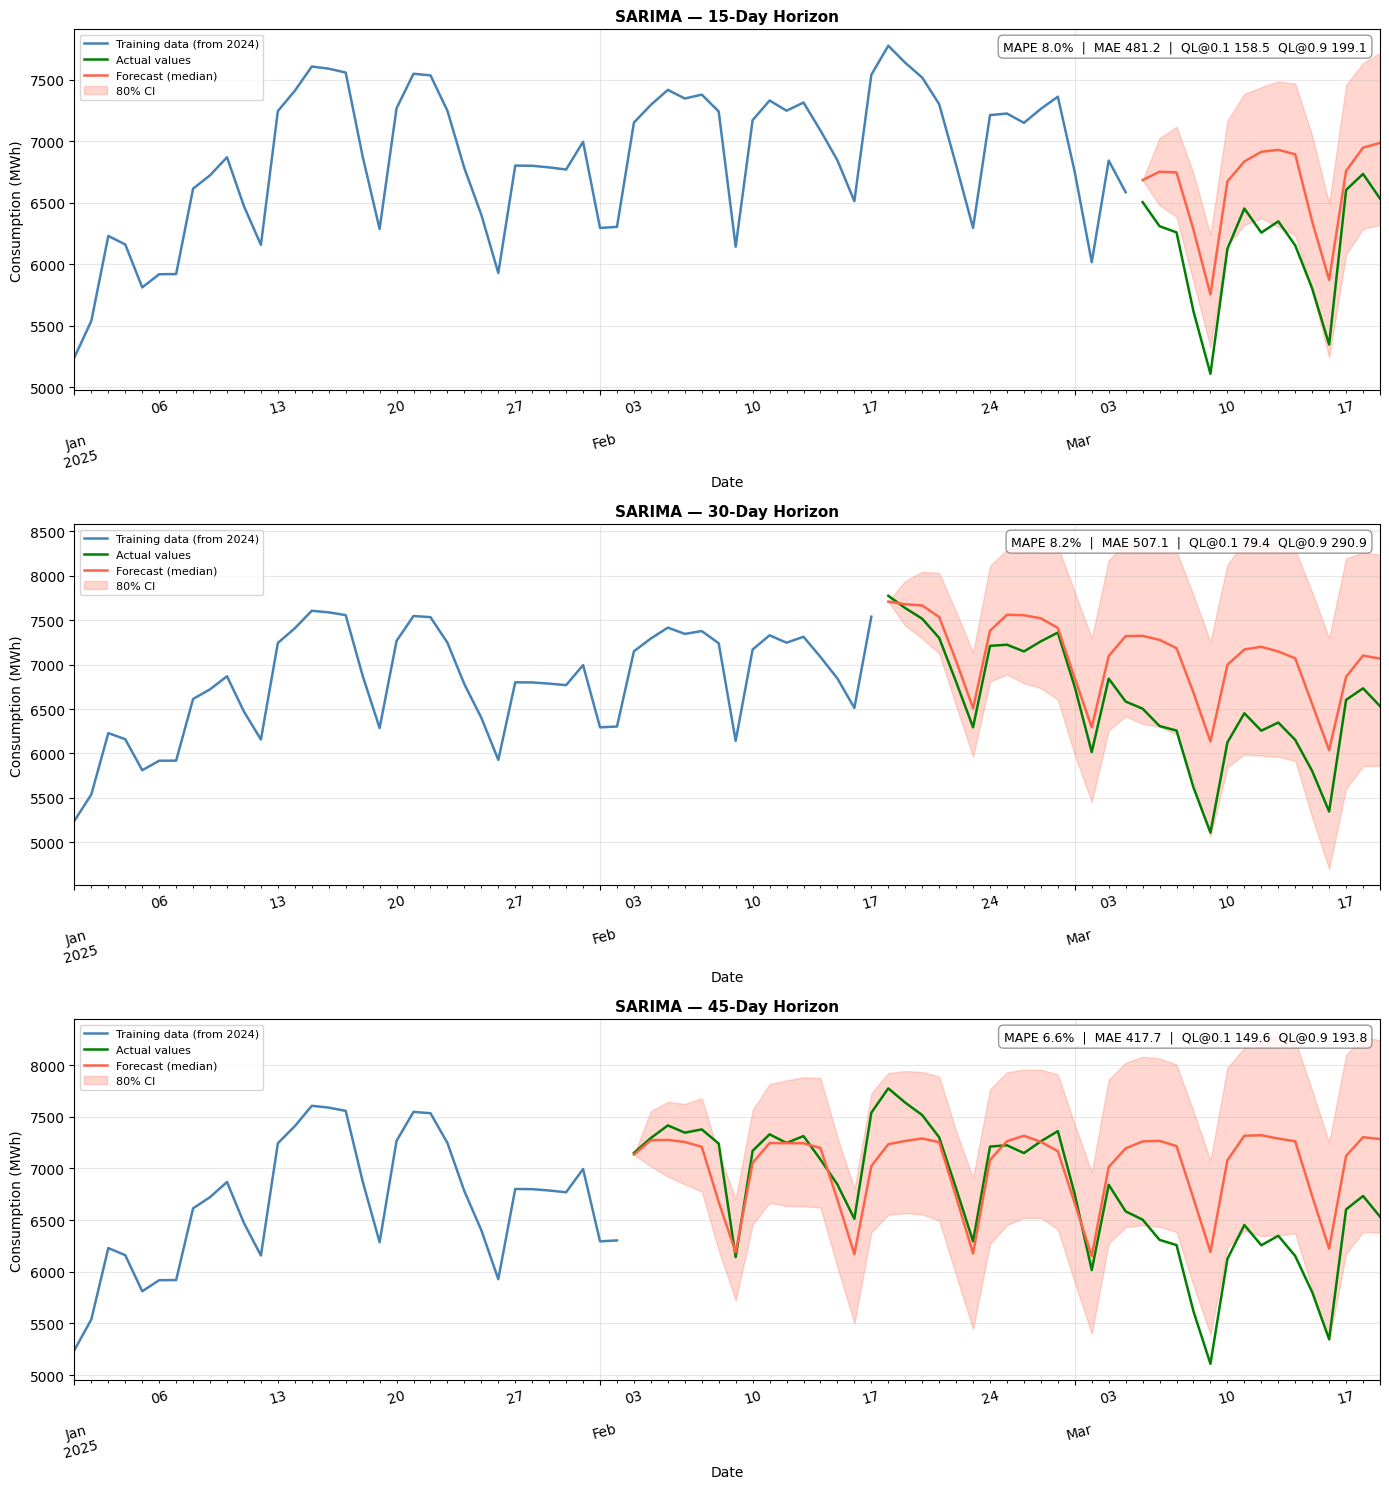

In [54]:
sarima_predictions = {}

for h in horizons:
    key = f"{h}-Day Horizon"
    model = ARIMA(p=2, d=1, q=2, seasonal_order=(1, 1, 1, 7))
    model.fit(train_splits[key])
    sarima_predictions[key] = model.predict(n=h, num_samples=500)

sarima_all_metrics = visualize_multi_forecast("SARIMA", sarima_predictions, train_splits, val_splits)

## Prophet

00:12:21 - cmdstanpy - INFO - Chain [1] start processing
00:12:21 - cmdstanpy - INFO - Chain [1] done processing
00:12:22 - cmdstanpy - INFO - Chain [1] start processing
00:12:23 - cmdstanpy - INFO - Chain [1] done processing
00:12:23 - cmdstanpy - INFO - Chain [1] start processing
00:12:24 - cmdstanpy - INFO - Chain [1] done processing


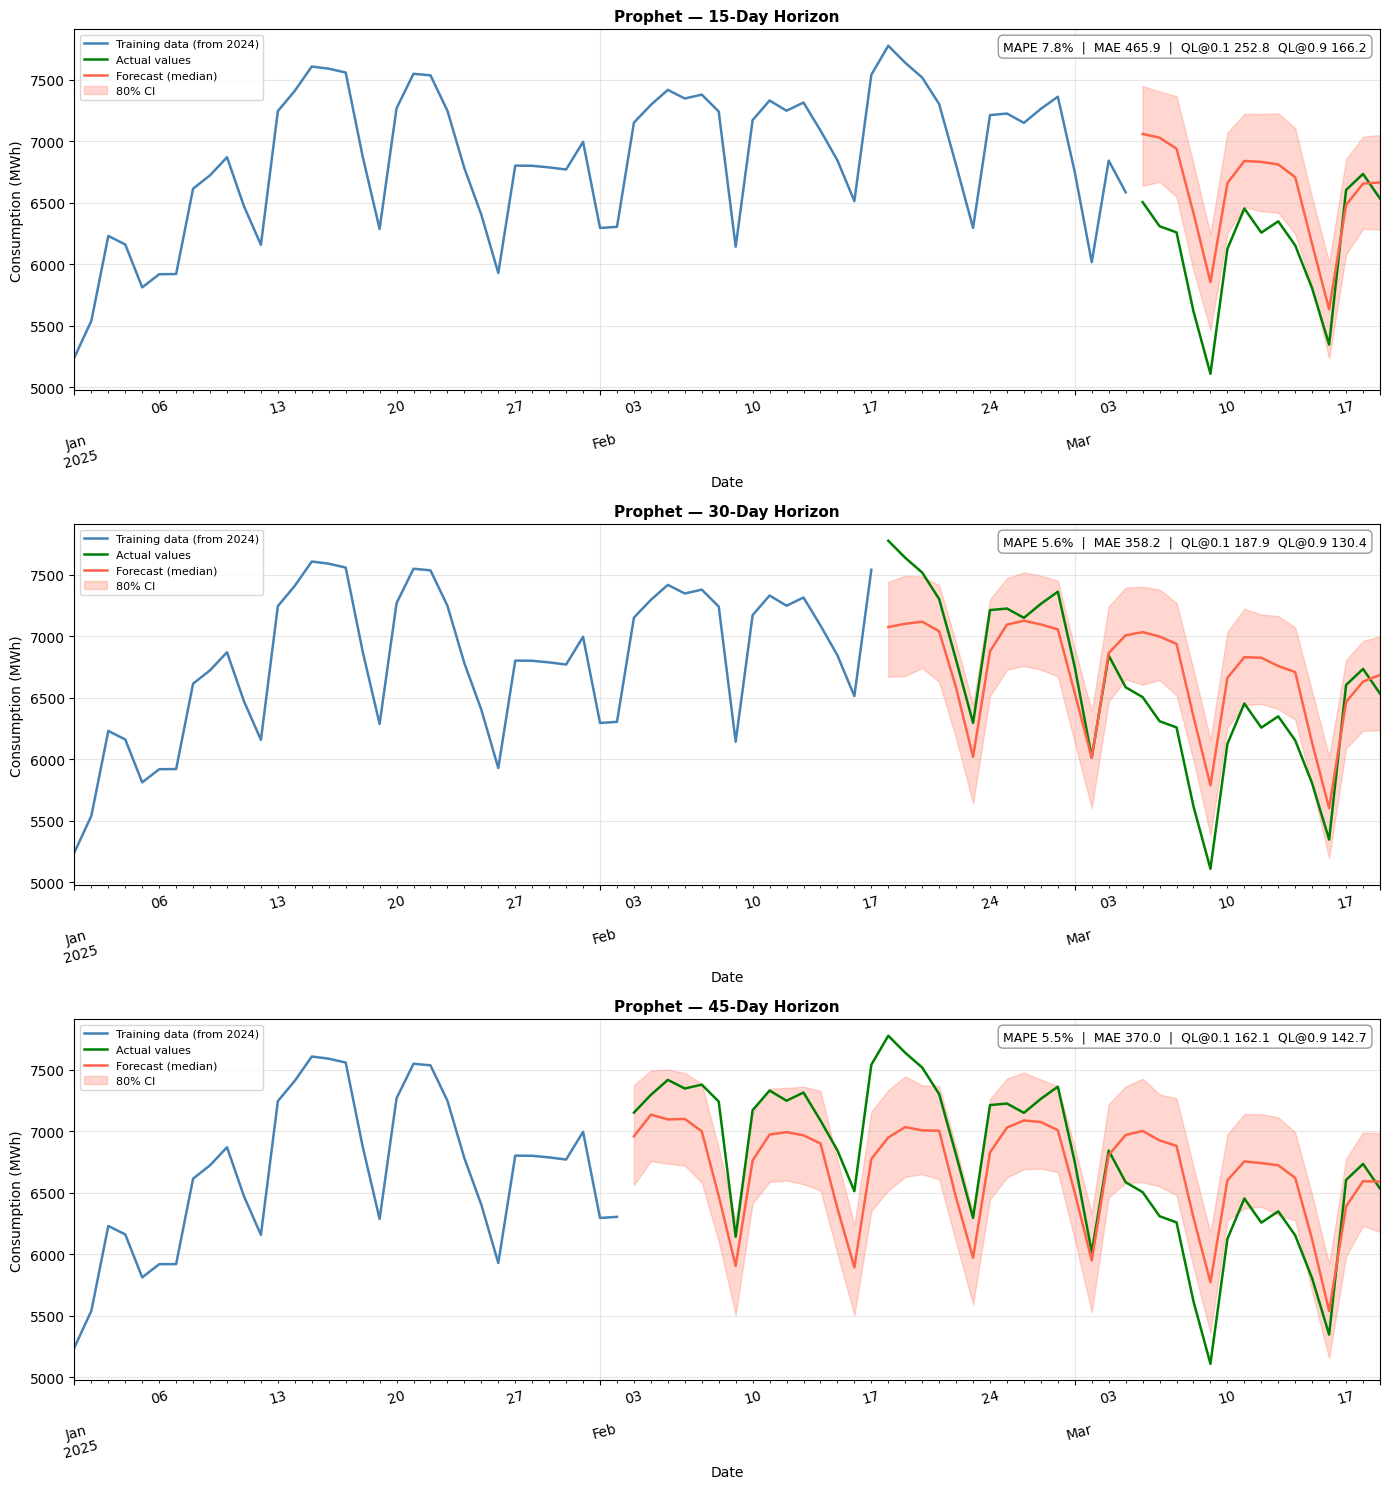

In [55]:
prophet_predictions = {}

for h in horizons:
    key = f"{h}-Day Horizon"
    model = Prophet(changepoint_prior_scale=0.05, seasonality_prior_scale=10.0)
    model.fit(train_splits[key])
    prophet_predictions[key] = model.predict(n=h, num_samples=500)

prophet_all_metrics = visualize_multi_forecast("Prophet", prophet_predictions, train_splits, val_splits)

### XGBoost

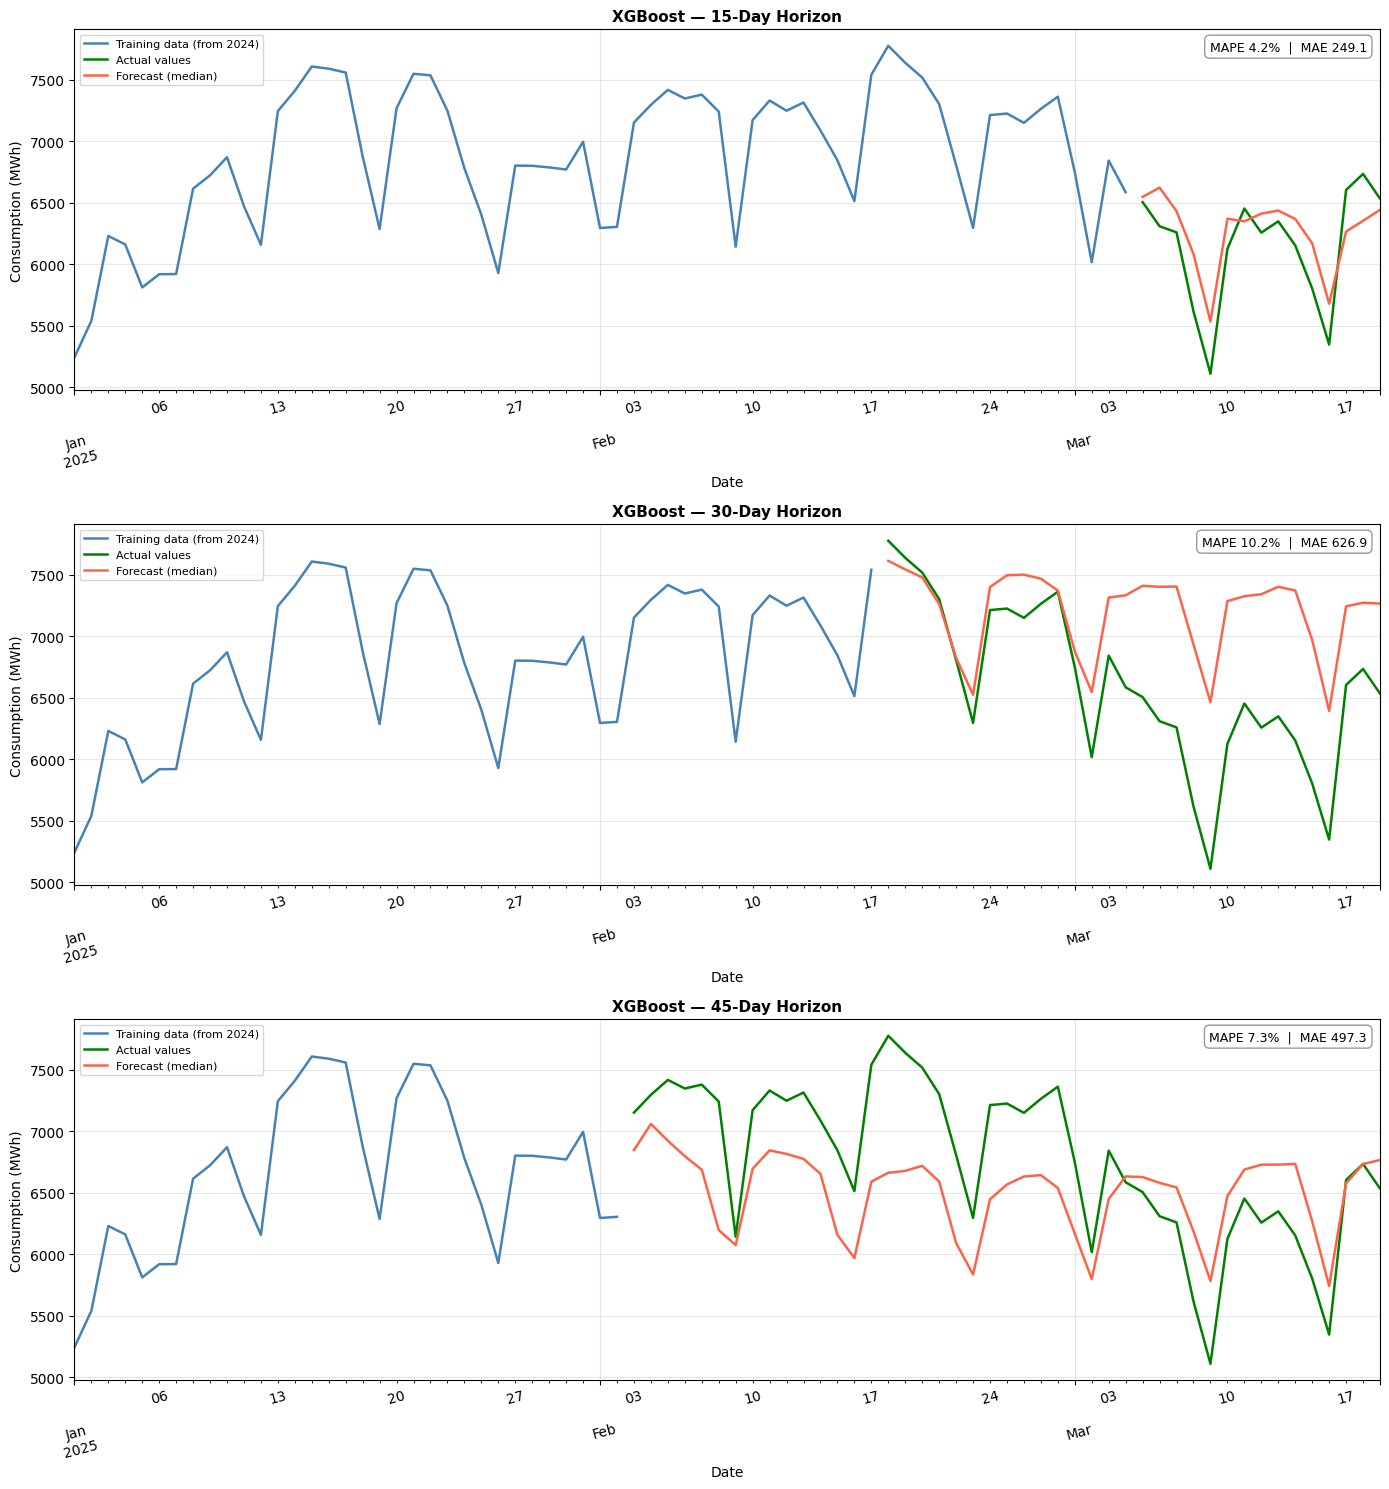

In [56]:
xgb_predictions = {}

for h in horizons:
    key = f"{h}-Day Horizon"
    model = XGBModel(lags=14, n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
    model.fit(train_splits[key])
    xgb_predictions[key] = model.predict(n=h, series=train_splits[key])

xgb_all_metrics = visualize_multi_forecast("XGBoost", xgb_predictions, train_splits, val_splits)

In [57]:
model_results = {
    "SARIMA":         sarima_all_metrics,
    "Prophet":        prophet_all_metrics,
    "XGBoost":        xgb_all_metrics,
}

rows = []
for model_name, metrics_by_horizon in model_results.items():
    for horizon, m in metrics_by_horizon.items():
        for metric, val in m.items():
            if val is not None:
                rows.append({"Model": model_name, "Metric": metric, "Horizon": horizon, "Value": val})

results_df = pd.DataFrame(rows)

pivot_table = results_df.pivot_table(index=["Model", "Metric"], columns="Horizon", values="Value")
pivot_table

Horizon           15-Day Horizon  30-Day Horizon  45-Day Horizon
Model   Metric                                                  
Prophet MAE              465.901         358.217         370.017
        MAPE (%)           7.759           5.582           5.527
        MSE           267770.514      175618.281      176592.782
        QL@0.1           252.798         187.858         162.083
        QL@0.9           166.220         130.415         142.710
SARIMA  MAE              481.239         507.140         417.661
        MAPE (%)           8.016           8.165           6.606
        MSE           262299.383      370559.348      318235.537
        QL@0.1           158.505          79.411         149.618
        QL@0.9           199.115         290.872         193.829
XGBoost MAE              249.125         626.898         497.289
        MAPE (%)           4.180          10.189           7.255
        MSE            79310.312      596615.661      316471.971

як на мене найкраще себе показала модель Prophet, я б вибрав її для даної задачі.